In [2]:
import os

if os.getcwd().split("/")[-1] != "neurolib":
    os.chdir('..')

os.chdir('..')
datadir = os.path.join(os.getcwd(), "neurolib", "whole-brain")
print(datadir)

/home/lena/Promotion/neurolib/neurolib/whole-brain


In [3]:
from neurolib.models.wc import WCModel
import matplotlib.pyplot as plt
import numpy as np
import scipy
import pickle

In [4]:
coords = [[1.6, 0.0], [1.7, 0.1]] #(B, A)

def setparams(model):
    model.params.c_excinh = 12  # local E-I coupling
    model.params.signalV = 80.0
    model.params.K_gl = 0.5  # global coupling strength
    model.params.a_exc = 1.  # excitatory gain
    model.params.a_inh = 1.  # inhibitory gain
    model.params.mu_exc = 5.0  # excitatory firing threshold
    model.params.mu_inh = 5.0  # inhibitory firing threshold



In [7]:
with open(os.path.join(datadir, 'prc.pickle'), 'rb') as f:
    data = pickle.load(f)
    
#prc_A = data[0]
prc_B = data[1]

[ 27726  73479 119231]
dt, a, w =  0.001 0.01 1000


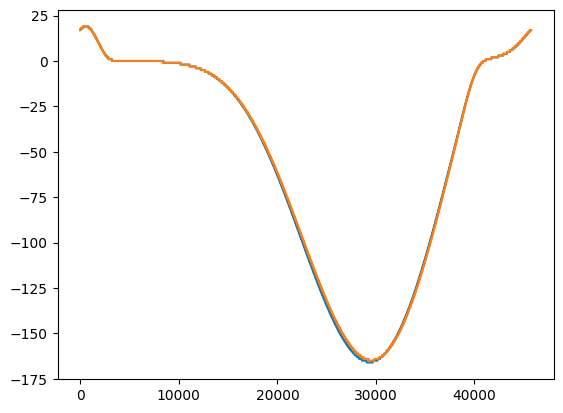

22.8765


In [ ]:
wc = WCModel()

setparams(wc)
wc.params.exc_ext_baseline = coords[0][0]
wc.params.inh_ext_baseline = coords[0][1]
wc.params.exc_init = np.zeros((1,1))
wc.params.inh_init = np.zeros((1,1))

dt = 0.001
wc.params.dt = dt

wc.params.duration = 135.
wc.run()

peaks = scipy.signal.find_peaks(wc.exc[0,:])[0]
print(peaks)

wc.params.exc_ext = np.zeros_like(wc.exc)
prc_B = np.zeros((peaks[1]-peaks[0]))
prc_min = np.zeros((peaks[1]-peaks[0]))

a = 0.01
w = 1000

print("dt, a, w = ", dt, a, w)

for t in range(peaks[0], peaks[1]):

    wc.params.exc_ext[0, t-w:t+w+1] += a
    wc.run()
    peaks1 = scipy.signal.find_peaks(wc.exc[0,:])[0]
    prc_B[t-peaks[0]] = (peaks1[-1] - peaks[-1])

    wc.params.exc_ext[0, t-w:t+w+1] -= 2*a
    wc.run()
    peaks1 = scipy.signal.find_peaks(wc.exc[0,:])[0]
    prc_min[t-peaks[0]] = (peaks1[-1] - peaks[-1])

    wc.params.exc_ext[0, t-w:t+w+1] = 0.
    

plt.plot(prc_B)
plt.plot(-prc_min)
plt.show()

[21242 59934 98624]
dt, a, w =  0.001 0.01 1000


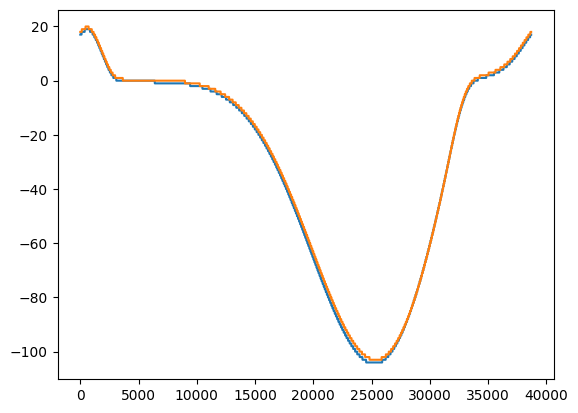

In [9]:
wc = WCModel()

setparams(wc)
wc.params.exc_ext_baseline = coords[1][0]
wc.params.inh_ext_baseline = coords[1][1]
wc.params.exc_init = np.zeros((1,1))
wc.params.inh_init = np.zeros((1,1))

for dt in [0.001]:
    wc.params.dt = dt

    wc.params.duration = 135.
    wc.run()

    peaks = scipy.signal.find_peaks(wc.exc[0,:])[0]
    print(peaks)

    wc.params.exc_ext = np.zeros_like(wc.exc)
    prc_A = np.zeros((peaks[1]-peaks[0]))
    prc_min = np.zeros((peaks[1]-peaks[0]))

    for a in [0.01]:
        for w in [1000]:

            print("dt, a, w = ", dt, a, w)

            for t in range(peaks[0], peaks[1]):

                wc.params.exc_ext[0, t-w:t+w+1] += a
                wc.run()
                peaks1 = scipy.signal.find_peaks(wc.exc[0,:])[0]
                prc_A[t-peaks[0]] = (peaks1[-1] - peaks[-1])

                wc.params.exc_ext[0, t-w:t+w+1] -= 2*a
                wc.run()
                peaks1 = scipy.signal.find_peaks(wc.exc[0,:])[0]
                prc_min[t-peaks[0]] = (peaks1[-1] - peaks[-1])

                wc.params.exc_ext[0, t-w:t+w+1] = 0.    

            plt.plot(prc_A)
            plt.plot(-prc_min)
            plt.show()

In [10]:
with open(os.path.join(datadir, 'prc.pickle'), 'wb') as f:
    pickle.dump([prc_A, prc_B], f)